# Clase 18: Limitaciones de Black-Scholes y Modelos de Volatilidad Estocástica

> **Objetivo:** Entender por qué el modelo BS es una simplificación útil pero incompleta, ver la evidencia empírica de sus fallas, y conocer los tres modelos que el mercado usa cuando BS no es suficiente. Incluyendo simulaciones en Python para cada uno.
> 

---

## 1. ¿Qué asume Black-Scholes?

El modelo descansa en cinco supuestos que el mercado viola sistemáticamente:

**Volatilidad constante:** BS asume que σ es la misma para todos los strikes y vencimientos. La superficie de volatilidad de la Clase 17 demuestra que esto es falso: cada opción tiene su propia IV.

**Retornos lognormales:** BS asume que los retornos diarios siguen una distribución normal. En la práctica, los mercados tienen *fat tails,* entiendase, eventos de −5% o −10% en un día ocurren con mucha más frecuencia de lo que la normal predice.

**Mercado continuo sin saltos:** BS asume que el precio se mueve suavemente. Los crashes de 2008, 2020 y 2022 son ejemplos de saltos abruptos que el modelo no puede capturar.

**Sin fricción:** sin costos de transacción, sin restricciones de venta en corto, liquidez infinita en todo momento.

**Tasa libre de riesgo constante:** en la práctica las tasas cambian, especialmente en horizontes largos.

---

### Modelo de Mov. Geométrico Browniano

$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$

| Componente | Significado |
| --- | --- |
| $\mu S_t \, dt$ | Drift determinista, crecimiento esperado |
| $\sigma S_t \, dW_t$ | Componente aleatoria, con σ **constante** |

## 2. La evidencia: distribución real vs. lognormal

La distribución empírica de retornos de SPY tiene dos características que BS ignora:

- **Curtosis excesiva > 0:** las colas son más gordas que la normal
- **Asimetría negativa:** los retornos negativos extremos son más frecuentes que los positivos equivalentes

Curtosis excess :15.17   (normal = 0)
Asimetría       :-0.32    (normal = 0)


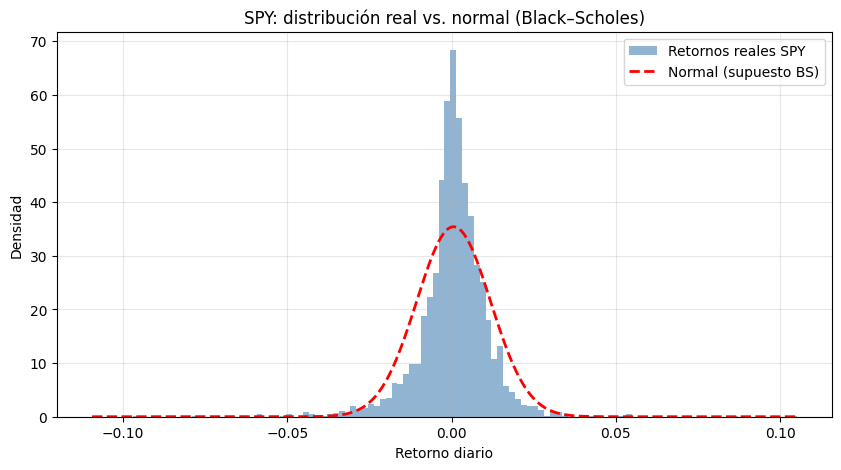

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew
import warnings
warnings.filterwarnings('ignore')

data     = yf.Ticker('SPY').history(period='10y')['Close']
retornos = data.pct_change().dropna()

print(f"Curtosis excess :{kurtosis(retornos):.2f}   (normal = 0)")
print(f"Asimetría       :{skew(retornos):.2f}    (normal = 0)")

x = np.linspace(retornos.min(), retornos.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(retornos, bins=120, density=True, alpha=0.6,
         color='steelblue', label='Retornos reales SPY')
plt.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
         'r--', linewidth=2, label='Normal (supuesto BS)')
plt.xlabel('Retorno diario')
plt.ylabel('Densidad')
plt.title('SPY: distribución real vs. normal (Black–Scholes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

```python

```

> Las colas de la distribución real son notablemente más anchas que las de la normal. Eso significa que BS subestima sistemáticamente la probabilidad de movimientos extremos y por tanto subpreciará las opciones muy OTM.
> 

---

## 3. Alternativas. Modelo de Heston (1993)

### Intuición

En BS, la volatilidad es un número fijo. En Heston, la volatilidad es en sí misma un proceso aleatorio que fluctúa en el tiempo pero tiende a regresar a un nivel promedio de largo plazo, igual que las tasas de interés. 

Cuando el mercado está nervioso, σ sube. Cuando se calma, σ baja. Esta dinámica genera naturalmente el skew que BS no puede producir.

### Ecuaciones

- Precios

$$
dS_t = \mu S_t \, dt + \sqrt{v_t} \, S_t \, dW_t^S
$$

- Volatilidades

$$
dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_t^v
$$

**Parte determinista:** $κ(θ−vt) dt$

Este término es la reversión a la media. Si $vt>θ$  (la varianza está alta, por encima de su nivel de largo plazo), entonces $(θ−vt)<0$ y el término jala $vt$ hacia abajo. Si $vt<θ$, jala hacia arriba. κ controla qué tan fuerte es ese jalón. Una $κ$ grande significa que la varianza regresa rápido a θ, $κ$ pequeña significa que puede alejarse mucho antes de regresar.

**Parte aleatoria:** $ξ\sqrt{v_t}dW_t^v$

La volatilidad también tiene su propio ruido aleatorio. $ξ$ (vol of vol) controla cuánto fluctúa σ alrededor de su media. Si $ξ$ = 0, la volatilidad sería determinista, siempre convergería a $θ$ sin desviarse.

### La conexión entre las dos: ρ

Los dos procesos brownianos $dW_t^S$ y $dW_t^v$ no son independientes — tienen
correlación ρ. En SPY, ρ ≈ −0.7, lo que significa que cuando el precio cae
($dW_t^S$ negativo), la volatilidad tiende a subir ($dW_t^v$ positivo). Eso es
el *leverage effect;* el fenómeno empírico de que los mercados se vuelven más
volátiles cuando caen.

Esa correlación negativa es exactamente lo que genera el skew: las opciones con
strikes bajos (protección contra caídas) son más caras porque cuando el precio
baja, σ sube y las opciones valen más.

### Simulación en Python
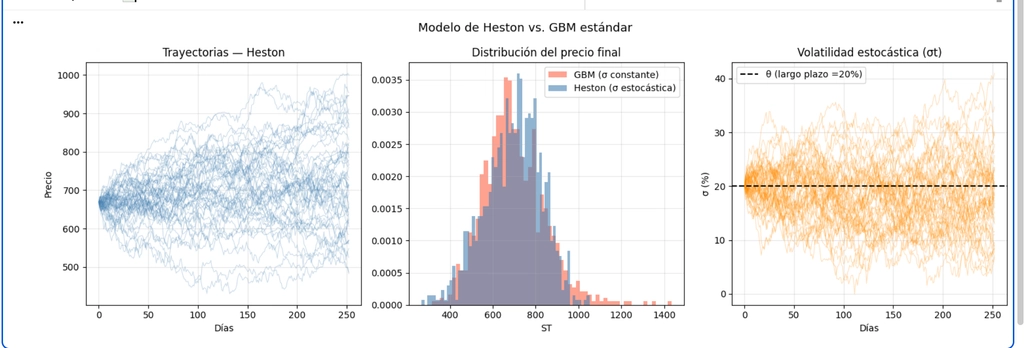

## Heston vs. GBM

**Trayectorias (izquierda):** Se ven más irregulares que el GBM estándar — hay períodos donde el abanico se abre más (alta volatilidad) y períodos donde se comprime (baja volatilidad). Eso es la volatilidad estocástica en acción: σ no es constante, respira.

**Distribución del precio final (centro):** Las dos distribuciones son casi idénticas en el centro — Heston y GBM producen precios similares en el escenario base. La diferencia está en las colas: Heston tiene más masa en los extremos, especialmente hacia la izquierda. Eso es exactamente el skew negativo que genera la correlación ρ = −0.7.

**Volatilidad estocástica (derecha):** Todas las trayectorias de σt oscilan alrededor de la línea punteada θ = 20% — la reversión a la media es visible. Algunas simulaciones suben hasta 35-40% (momentos de stress) y luego regresan. Eso captura lo que vemos empíricamente: la volatilidad de SPY sube en crisis y luego se normaliza.

---

> Observa en la gráfica del centro que la distribución de Heston tiene colas más anchas que GBM; especialmente hacia la izquierda. Esa asimetría es exactamente el skew negativo que vimos en la superficie de volatilidad.
>

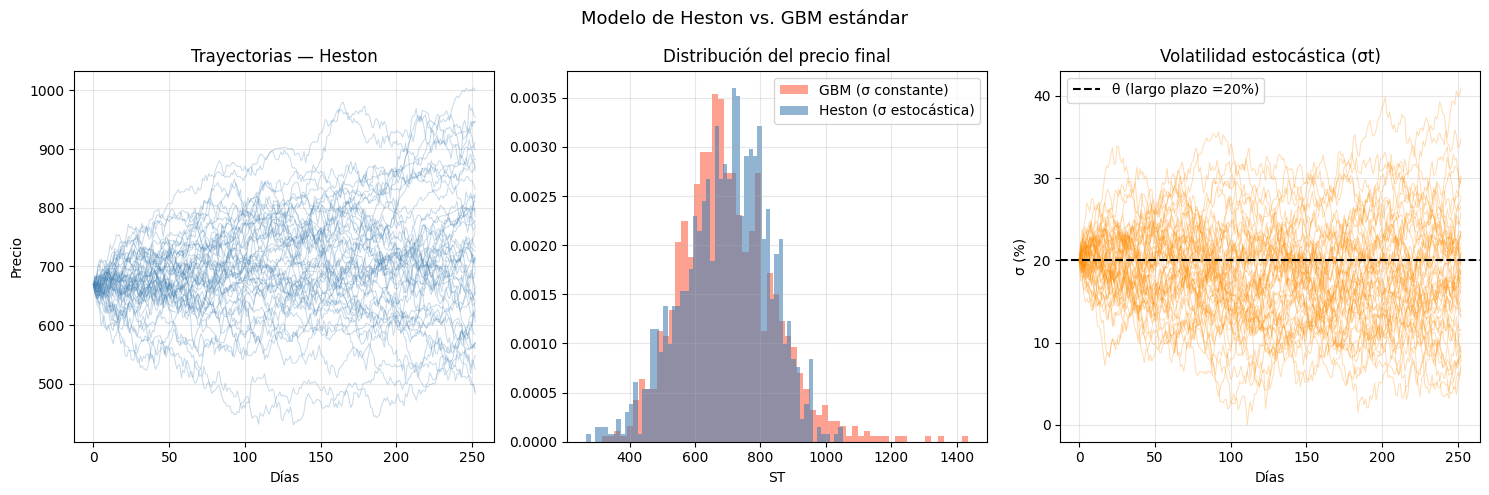

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# --- Comparación: GBM estándar vs. Heston ---
sigma_const = 0.20
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trayectorias
for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Distribución final: GBM vs Heston
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Evolución de la varianza
for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Modelo de Saltos de Merton (1976)

### Intuición

GBM y Heston asumen que el precio se mueve continuamente — nunca da saltos bruscos. Pero en la realidad, eventos como un crash, un dato de inflación sorpresivo o una quiebra bancaria hacen que el precio salte discontinuamente de un nivel a otro. Merton agrega un proceso de Poisson al GBM para capturar exactamente esos saltos.

La pregunta que responde el modelo: ¿con qué frecuencia salta el mercado, y qué tan grandes son esos saltos?

### Ecuación

$$
dS = \mu S \, dt + \sigma S \, dW + S \, dJ
$$

Donde $dJ$ es un proceso de salto compuesto:

$$
dJ = \sum_{i=1}^{N(t)} (Y_i - 1)
$$

- $N(t)$: proceso de Poisson con intensidad $\lambda$ (número esperado de saltos por año)
- $Y_i$: magnitud del salto $i$, donde $\ln(Y_i) \sim \mathcal{N}(\mu_J, \sigma_J^2)$

Este término $dJ$ tiene dos componentes anidados:

**$N(t)$: cuántos saltos ocurren**

Es un proceso de Poisson con intensidad λ. En cada instante pequeño $dt$, la
probabilidad de que ocurra un salto es aproximadamente $\lambda \cdot dt$. Si
λ = 4, el mercado salta en promedio 4 veces al año — aproximadamente una vez
cada trimestre.

Entre saltos, el precio se mueve normalmente con GBM. Los saltos son eventos
discretos e instantáneos.

**$Y_i$: qué tan grande es cada salto**

Cuando ocurre el salto $i$, el precio se multiplica por $Y_i$. El término
$(Y_i - 1)$ es el retorno neto del salto:

- Si $Y_i = 0.85$ → el precio cae 15% instantáneamente
- Si $Y_i = 1.10$ → el precio sube 10% instantáneamente

La magnitud se modela como lognormal: $\ln(Y_i) \sim \mathcal{N}(\mu_J, \sigma_J^2)$,
lo que garantiza que $Y_i > 0$ ; el precio nunca puede volverse negativo por un salto.

| Parámetro | Significado | Valor típico |
| --- | --- | --- |
| $\lambda$ | Saltos esperados por año | 3–5 |
| $\mu_J$ | Media del log-salto | −0.10 (saltos negativos) |
| $\sigma_J$ | Desviación del log-salto | 0.15 |

Con $\mu_J = -0.10$, el salto promedio es una caída de ~10%. Con $\sigma_J = 0.15$,
hay dispersión, algunos saltos son pequeños, otros son grandes.

### Simulación en Python

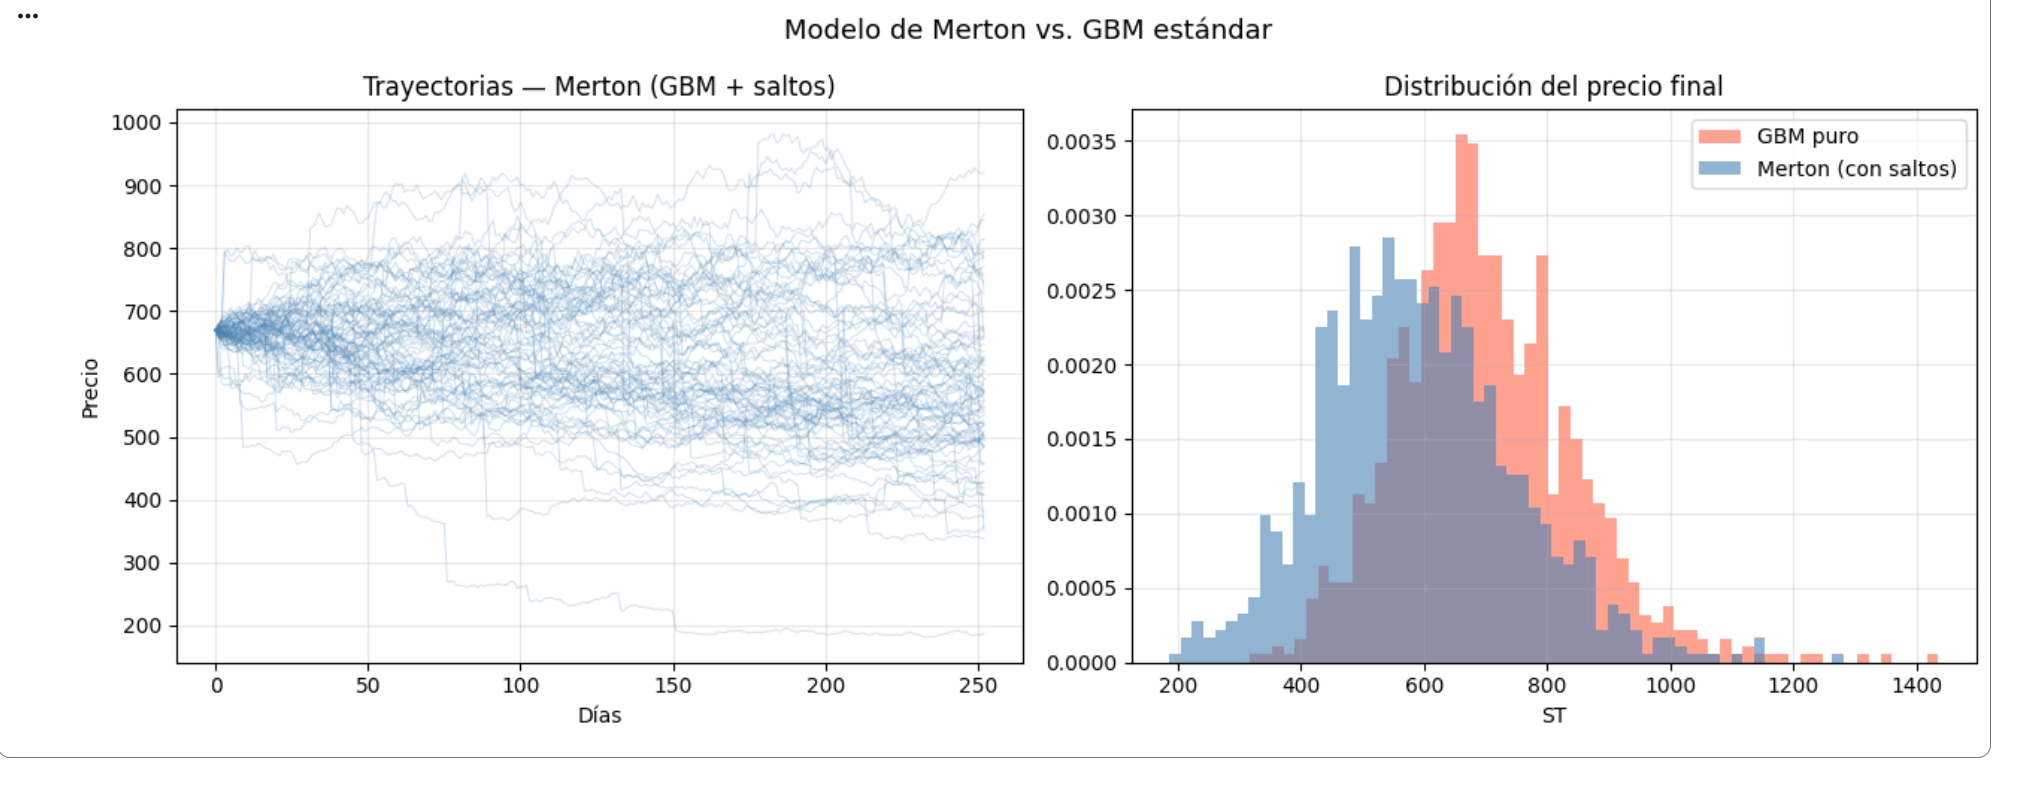

## Merton vs. GBM

**Trayectorias (izquierda):** Aquí se ven las discontinuidades — algunas trayectorias tienen caídas abruptas verticales, especialmente visible en las líneas que bajan a 200-300. Esos son los saltos de Poisson: el precio no llega gradualmente a 300, cae de golpe. El abanico general está desplazado hacia abajo vs. GBM porque los saltos tienen media negativa (μⱼ = −0.05).

**Distribución del precio final (derecha):** Esta es la diferencia más importante entre los dos modelos. Merton desplaza toda la distribución hacia la izquierda — el precio esperado al final es menor que con GBM puro porque los saltos negativos acumulados arrastran el precio hacia abajo. Además la cola izquierda de Merton es mucho más gruesa: hay escenarios donde SPY termina en 200-300, algo que GBM considera prácticamente imposible. Esa cola izquierda es el riesgo de crash que BS subestima sistemáticamente.

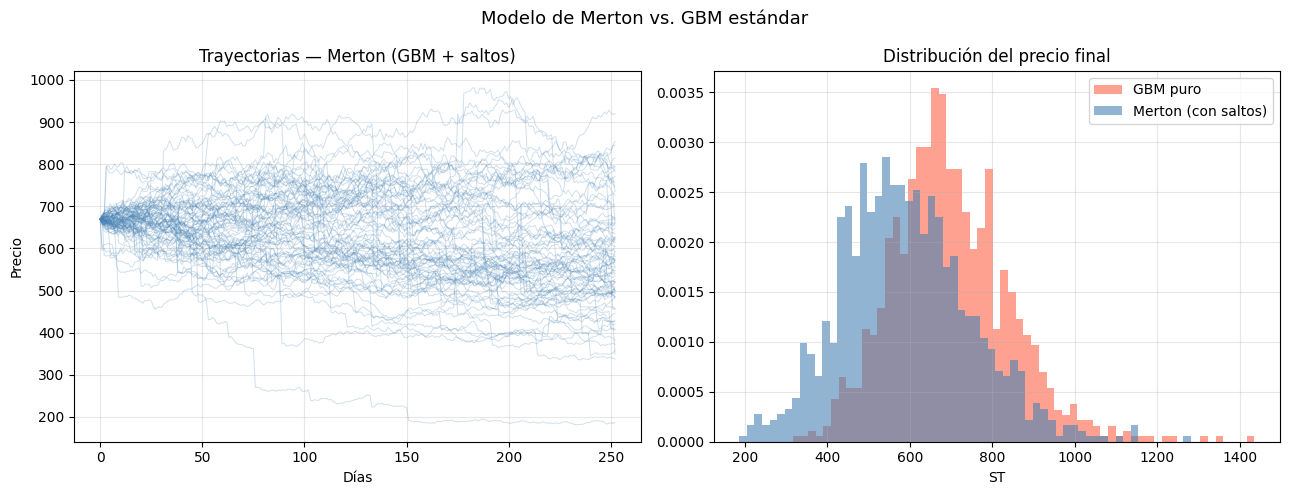

In [3]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias — algunos saltos visibles
for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Comparación distribución final
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

> En las trayectorias de Merton verás discontinuidades visibles, el precio se *teleporta* de un nivel a otro. Eso es exactamente lo que los modelos continuos como BS no pueden representar.
> 

---

## 5. Comparación de los tres modelos

|  | GBM / BS | Heston | Merton |
| --- | --- | --- | --- |
| **Volatilidad** | Constante | Estocástica, reversión a la media | Constante entre saltos |
| **Saltos** | No | No | Sí (Poisson) |
| **Skew generado** | No | Sí (por correlación ρ) | Sí (por saltos negativos) |
| **Fat tails** | No | Parcialmente | Sí |
| **Complejidad** | Baja | Media | Media |
| **Uso principal** | Referencia universal | Derivados de renta variable | Opciones de muy corto plazo, OTM |
| **Parámetros** | 1 (σ) | 5 (κ, θ, ξ, ρ, v₀) | 3 (λ, μⱼ, σⱼ) |
|  |  |  |  |

## Tabla resumen

|  | Proceso del precio | Modelo de pricing equivalente |
| --- | --- | --- |
| **GBM (σ constante)** | $dS=μSdt+σSdW$ | Black-Scholes |
| **Heston** | GBM + varianza estocástica | Heston (fórmula semi-analítica) |
| **Merton** | GBM + saltos de Poisson | Merton (serie infinita) |

## 6. ¿Entonces por qué usamos BS?

A pesar de sus limitaciones, BS sigue siendo el lenguaje universal del mercado de opciones, quizá no como modelo de pricing pero sí como sistema de cotización. Los traders no cotizan precios en dólares, cotizan volatilidades implícitas. BS es la calculadora que convierte entre los dos.

La superficie de volatilidad *es* el reconocimiento colectivo de que BS está mal, y a la vez la herramienta que los traders usan para trabajar con esa imperfección de forma práctica. Aprender BS no es aprender un modelo correcto; es aprender el idioma del mercado.

Heston y Merton no reemplazan a BS en la práctica diaria, lo complementan. Se usan para calibrar la superficie, para pricing de productos exóticos, y para análisis de riesgo de cola. Para estrategias estándar con opciones líquidas, BS con la IV correcta sigue siendo el punto de partida.

---

## Actividad: **Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos**

https://canvas.iteso.mx/courses/54243/assignments/1157688

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros generales base (puedes ajustarlos a los de tu clase)
S0 = 100.0      # Precio inicial
r = 0.05        # Tasa libre de riesgo
T = 1.0         # Tiempo al vencimiento (1 año)
N = 252         # Pasos de tiempo (días de trading)
M = 10000       # Número de trayectorias
dt = T / N

# --- FUNCIÓN 1: Simulación GBM (Black-Scholes) ---
def simulate_gbm(S0, r, sigma, T, N, M):
    dt = T / N
    S = np.zeros((N + 1, M))
    S[0] = S0
    for t in range(1, N + 1):
        Z = np.random.standard_normal(M)
        S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return S[-1] # Retornamos solo los precios finales

In [6]:
# --- FUNCIÓN 2: Simulación Heston ---
def simulate_heston(S0, r, v0, kappa, theta, xi, rho, T, N, M):
    dt = T / N
    S = np.zeros((N + 1, M))
    v = np.zeros((N + 1, M))
    S[0] = S0
    v[0] = v0
    
    for t in range(1, N + 1):
        Z1 = np.random.standard_normal(M)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(M)
        
        # Volatilidad (Asegurando que no sea negativa con abs)
        v[t] = np.abs(v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(v[t-1]) * np.sqrt(dt) * Z2)
        # Precio
        S[t] = S[t-1] * np.exp((r - 0.5 * v[t]) * dt + np.sqrt(v[t]) * np.sqrt(dt) * Z1)
        
    return S[-1]

In [7]:

# --- FUNCIÓN 3: Simulación Merton (Jump Diffusion) ---
def simulate_merton(S0, r, sigma, lam, m, v, T, N, M):
    dt = T / N
    S = np.zeros((N + 1, M))
    S[0] = S0
    
    # Compensador de salto
    k = np.exp(m + 0.5 * v**2) - 1
    
    for t in range(1, N + 1):
        Z = np.random.standard_normal(M)
        # Número de saltos en dt
        N_jumps = np.random.poisson(lam * dt, M)
        
        # Multiplicador de salto total en este paso
        J_mult = np.ones(M)
        for i in range(M):
            if N_jumps[i] > 0:
                Z_jump = np.random.standard_normal(N_jumps[i])
                jumps = np.exp(m + v * Z_jump)
                J_mult[i] = np.prod(jumps)
                
        S[t] = S[t-1] * np.exp((r - lam * k - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z) * J_mult
        
    return S[-1]

In [8]:
# Parámetros base para Heston
v0, kappa, theta, rho = 0.04, 2.0, 0.04, -0.7
# Parámetros base para Merton
sigma_m, m_jump, v_jump = 0.2, -0.1, 0.15 
# Volatilidad equivalente para BS
sigma_bs = 0.2 

GBM_final = simulate_gbm(S0, r, sigma_bs, T, N, M)

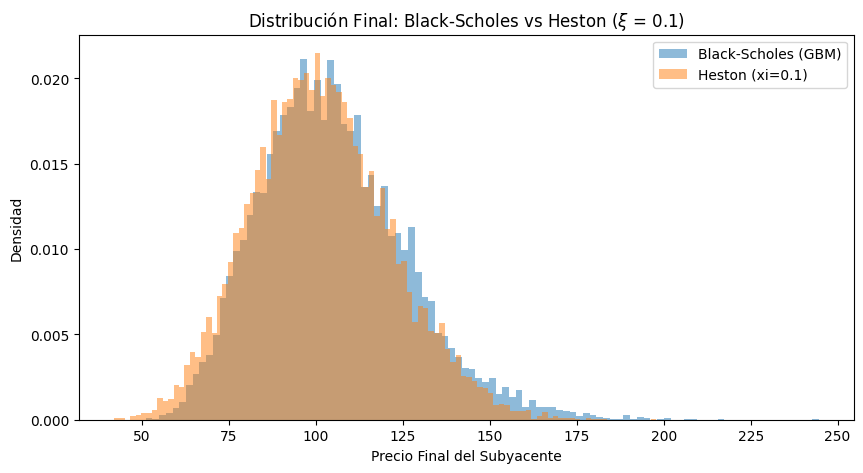

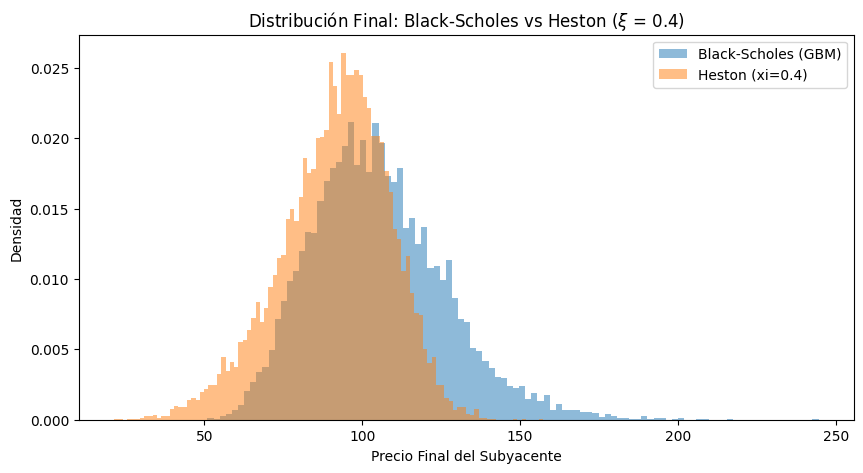

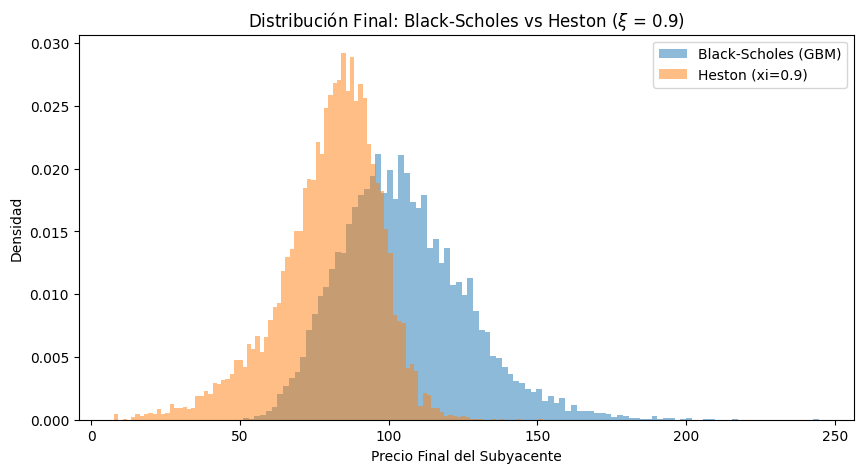

In [11]:

# 1. Variaciones Heston: xi = 0.1, 0.4, 0.9
xi_values = [0.1, 0.4, 0.9]
for xi in xi_values:
    Heston_final = simulate_heston(S0, r, v0, kappa, theta, xi, rho, T, N, M)
    plt.figure(figsize=(10, 5))
    plt.hist(GBM_final, bins=100, alpha=0.5, label='Black-Scholes (GBM)', density=True)
    plt.hist(Heston_final, bins=100, alpha=0.5, label=f'Heston (xi={xi})', density=True)
    # CORRECCIÓN: Se agregó 'r' antes de la 'f' para evitar el error de unicode en \xi
    plt.title(rf'Distribución Final: Black-Scholes vs Heston ($\xi$ = {xi})')
    plt.xlabel('Precio Final del Subyacente')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

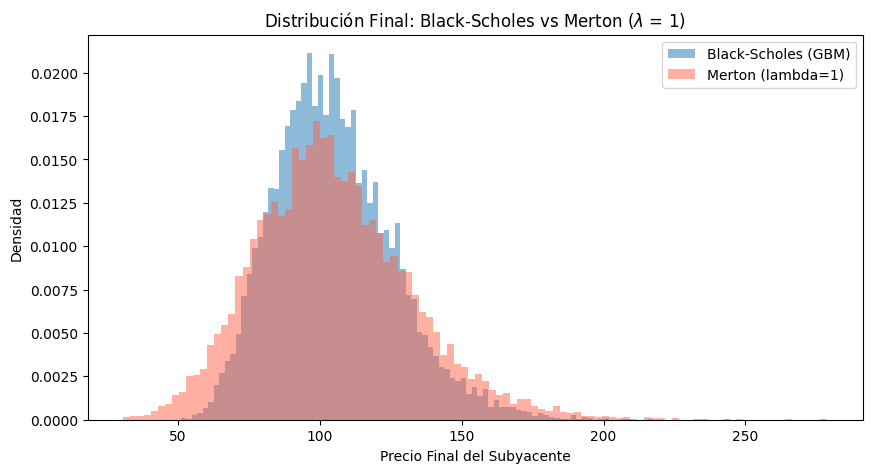

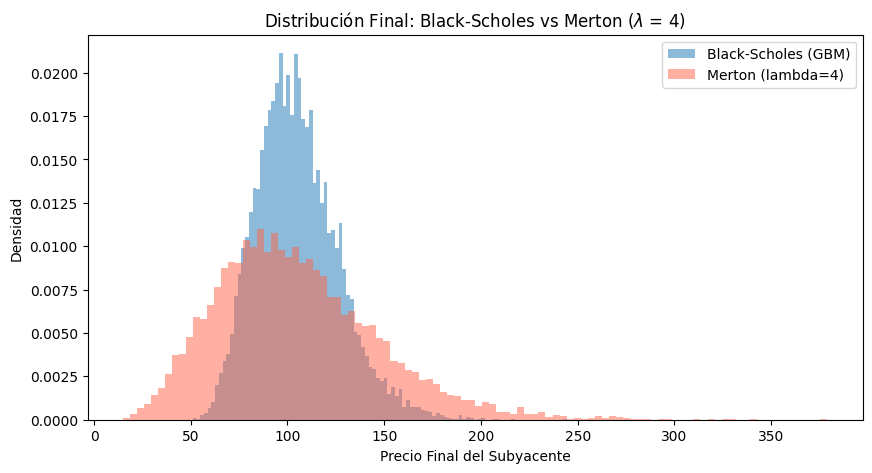

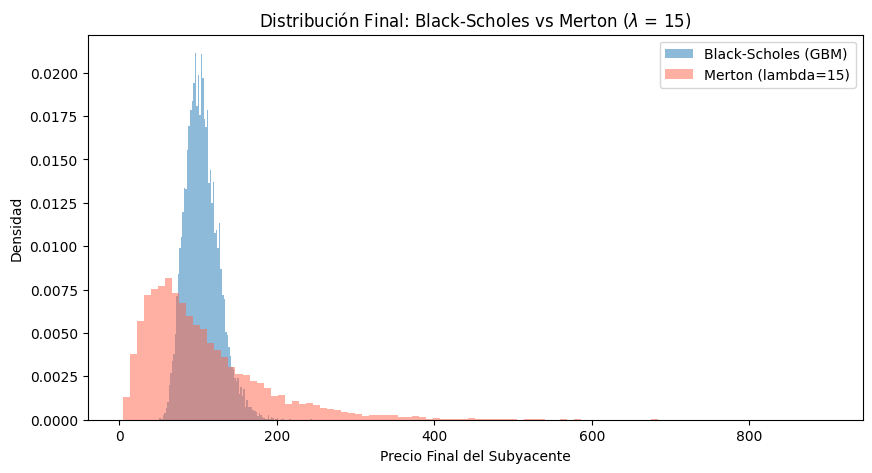

In [15]:
# 2. Variaciones Merton: lambda = 1, 4, 15
lam_values = [1, 4, 15]
for lam in lam_values:
    Merton_final = simulate_merton(S0, r, sigma_m, lam, m_jump, v_jump, T, N, M)
    plt.figure(figsize=(10, 5))
    plt.hist(GBM_final, bins=100, alpha=0.5, label='Black-Scholes (GBM)', density=True)
    plt.hist(Merton_final, bins=100, alpha=0.5, color='tomato', label=f'Merton (lambda={lam})', density=True)
    # CORRECCIÓN: Se agregó 'r' antes de la 'f' para evitar el error de unicode en \lambda
    plt.title(rf'Distribución Final: Black-Scholes vs Merton ($\lambda$ = {lam})')
    plt.xlabel('Precio Final del Subyacente')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

## Preguntas

- **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?** 

*Respuesta:*
Aumentar $\xi$ (la volatilidad de la volatilidad) ensancha significativamente las colas de la distribución o sea aumenta la curtosis. La varianza del precio fluctúa de manera mucho más salvaje. Respecto al skew (asimetría), debido a que típicamente usamos una correlación negativa ($\rho < 0$) entre el precio y la volatilidad, un mayor $\xi$ irrita esta asimetría negativa. Las caídas de precio vienen acompañadas de picos de volatilidad mucho más grandes, arrastrando una "cola gorda" más pronunciada hacia el lado izquierdo de la distribución final en comparación con el modelo de Black-Scholes.

- **En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

*Respuesta:*
Al cambiar $\lambda$ de 4 a 10, aumentamos la frecuencia promedio de los saltos. En las trayectorias, observamos que el precio se vuelve mucho más errático o "picado", mostrando discontinuidades de forma mucho más constante a lo largo del año. En cuanto a la distribución final, una mayor frecuencia de saltos incrementa la varianza total del proceso. La distribución adquiere colas mucho más pesadas (fat tails) y el centro de la campana suele achatarse en comparación con un $\lambda$ menor, distorsionando fuertemente la forma lognormal estándar de Black-Scholes.

- **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?**

*Respuesta:*
Estará fuertemente subestimado. Un put muy Out-of-The-Money (OTM) es esencialmente un seguro contra colapsos severos del mercado (eventos extremos en la cola izquierda). Al asumir una distribución lognormal, Black-Scholes asigna una probabilidad casi nula a que ocurran caídas del 10% o 20% en poco tiempo. Sin embargo, dado que el mercado real tiene "fat tails", la probabilidad real de que la opción termine In-The-Money es mucho más alta de lo que cree BS. Por lo tanto, el mercado cobrará mucho más por ese Put de lo que la fórmula teórica sugiere.


- **Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?**

*Respuesta:*
En la realidad financiera, los saltos abruptos o "crashes" no ocurren con una probabilidad constante a lo largo del tiempo. Los mercados exhiben un fenómeno llamado volatility clustering (agrupamiento de volatilidad). Los saltos tienden a concentrarse en periodos de pánico, estrés o crisis financiera, y son muy raros en mercados alcistas o tranquilos. Al mantener $\lambda$ constante, el modelo de Merton es incapaz de capturar que el riesgo de saltos es estocástico y depende fuertemente del régimen o estado macroeconómico en el que se encuentre el mercado.

- **¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?**
*Respuesta:*
Porque Black-Scholes funciona como un lenguaje universal o "calculadora de mercado", no como una verdad predictiva absoluta. Posee una fórmula analítica cerrada que es extremadamente rápida de calcular y fácilmente invertible. Esto permite que los traders conviertan instantáneamente un precio en dólares a una "Volatilidad Implícita" (IV). A pesar de sus deficiencias, los operadores del mercado corrigen los errores de BS simplemente ajustando la IV que ingresan según el strike (creando la superficie de volatilidad). Modelos como Heston y Merton requieren métodos numéricos costosos y calibración de múltiples parámetros complejos, lo cual los hace excelentes para el análisis de riesgos, pero muy ineficientes como sistema de cotización en tiempo real.
